Saving Mall_Customers.csv to Mall_Customers.csv
Dataset Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              40 non-null     int64 
 1   Gender                  40 non-null     object
 2   Age                     40 non-null     int64 
 3   Annual Income (k$)      40 non-null     int64 
 4   Spending Score (1-100)  40 non-null     int64 
dtypes: int64(4), object(1)


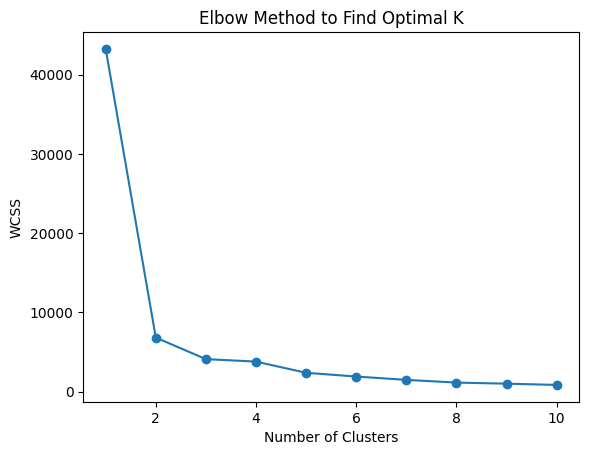


Clustered Data:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        1  
2        0  
3        1  
4        2  


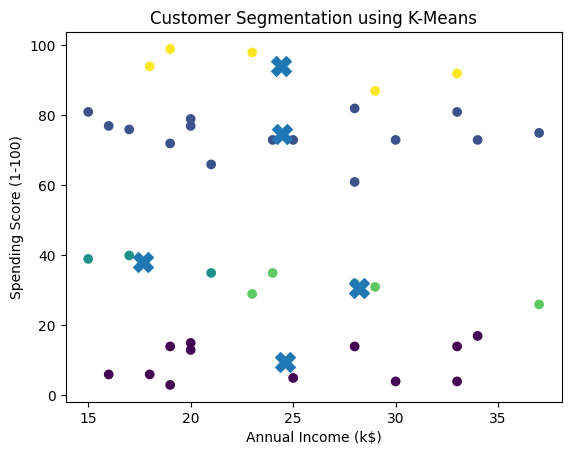


Number of customers in each cluster:
Cluster
1    15
0    12
4     5
3     5
2     3
Name: count, dtype: int64


In [2]:
#CustomerSegmentation(18-3-2026)
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from google.colab import files
uploaded = files.upload()
# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Display first few rows
print("Dataset Preview:")
print(df.head())

# Check dataset info
print("\nDataset Info:")
print(df.info())

# Selecting features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Finding optimal clusters using Elbow Method
wcss = []  # Within Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method to Find Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply KMeans with optimal clusters (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Display clustered data
print("\nClustered Data:")
print(df.head())

# Plot clusters
plt.figure()
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=df['Cluster'])
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")
plt.show()

# Show cluster counts
print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts())
